[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/07_joint_distributions_and_multivariate_normal/first_principles.ipynb)

# Module 07 — Joint Distributions and the Multivariate Normal

## 1. Why This Module Exists

Nothing interesting is one-dimensional. A pixel is meaningless without its neighbours; a stock return matters only relative to the market; a sensor reading is useful only when fused with the others. The object that carries all of this is the **joint distribution**,

$$
F_{\mathbf{X}}(\mathbf{x}) = P\left(X_1 \le x_1, \ldots, X_d \le x_d\right),
$$

and the essential fact about it is asymmetric: the joint always determines the marginals (integrate out what you do not want), but the marginals never determine the joint. The missing ingredient is the **dependence structure**, and Sklar's theorem makes the separation exact — a joint law with continuous marginals factors into those marginals plus a copula, and the copula is a free modeling choice.

Dependence is also what makes multivariate probability hard. A general joint density over $d$ variables is an object on $\mathbb{R}^d$; estimating it from data is hopeless without structure. Two kinds of structure rescue the situation. **Conditional independence** cuts the joint into small factors, which is the basis of graphical models. **Gaussianity** collapses everything into a mean vector and a covariance matrix and — remarkably — keeps every operation we care about inside the family.

This module builds the second structure completely. Two matrices carry the whole story: the covariance $\Sigma$, whose eigenvectors are principal components and whose Cholesky factor both samples and whitens, and the precision $\Theta = \Sigma^{-1}$, whose zero pattern is the conditional-independence graph. Marginal and conditional independence are different questions, and they live in different matrices.

### 1.1 Why the Multivariate Normal Is the Only Fully Tractable Multivariate Family

For $\mathcal{N}(\boldsymbol\mu, \Sigma)$ every standard operation has a closed form, and each one is a matrix computation:

| Operation | Result | Cost |
|---|---|---|
| Affine map $A\mathbf{X}+\mathbf{b}$ | $\mathcal{N}\left(A\boldsymbol\mu+\mathbf{b},\, A\Sigma A^{\top}\right)$ | one matrix product |
| Marginalize a block | drop the corresponding rows and columns of $\boldsymbol\mu, \Sigma$ | free |
| Condition on a block | Gaussian, linear mean shift, covariance $\Sigma_{11}-\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$ | one solve |
| Sum of independent Gaussians | add means, add covariances | free |
| Sample | $\boldsymbol\mu + L\mathbf{z}$ with $\Sigma = LL^{\top}$ | one Cholesky |
| Conditional independence test | check whether $\Theta_{ij} = 0$ | one factorization |

No other multivariate family closes under all of these. That is why Gaussian assumptions are the default in Kalman filtering, Gaussian processes, linear-Gaussian state-space models, and the forward and reverse kernels of diffusion models — not because data is Gaussian, but because the algebra survives contact with the algorithm.

## 2. Intuition

Three pictures carry every formula in this module.

**The joint is a landscape; the marginal is its shadow.** Draw the density $f_{X_1,X_2}$ as a surface over the plane. Integrating out $x_2$ presses the surface flat against the $x_1$ axis. Shadows lose information: two very different landscapes can cast identical shadows on both axes, which is exactly the statement that marginals do not determine the joint.

**The conditional is a slice, renormalized.** Fix $x_2 = c$ and cut the landscape with a vertical plane. The cross-section is a curve in $x_1$; divide it by its own area and it becomes a probability density. For a Gaussian landscape the cross-section of $\exp(-\text{quadratic})$ is again $\exp(-\text{quadratic})$, so every slice is Gaussian — and, because the quadratic's leading coefficient in $x_1$ does not involve $c$, every slice has the *same width*. Only the centre moves, and it moves linearly in $c$. That single geometric observation is the Gaussian conditioning rule.

**The Gaussian is an ellipse.** The level sets of $(\mathbf{x}-\boldsymbol\mu)^{\top}\Sigma^{-1}(\mathbf{x}-\boldsymbol\mu)$ are concentric ellipsoids centred at $\boldsymbol\mu$, with principal axes along the eigenvectors of $\Sigma$ and semi-axis lengths proportional to $\sqrt{\lambda_i}$. Everything geometric about a Gaussian — principal components, whitening, confidence regions, Mahalanobis outlier scores — is a statement about that one ellipsoid.

The figure below draws the second and third pictures together: contours of a correlated bivariate Gaussian with its eigen-axes, a conditioning slice at $x_2 = 1.5$, and the resulting conditional density compared against the marginal.

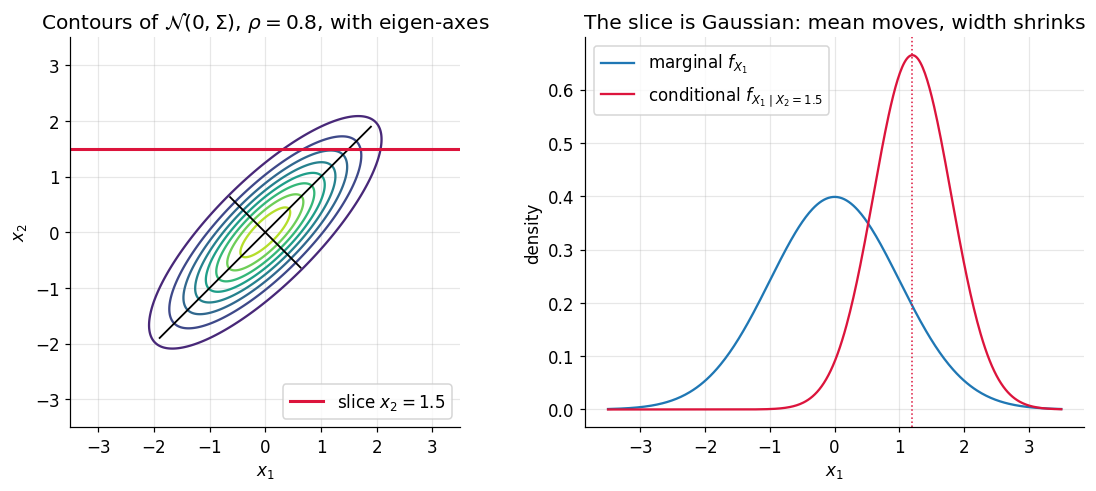

conditional mean  = 1.2000   (marginal mean 0)
conditional var   = 0.3600   (marginal var 1.0000)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy.stats import chi2, norm, multivariate_normal

# Figure: conditioning as a slice of the Gaussian landscape.
mu_fig = np.array([0.0, 0.0])
Sig_fig = np.array([[1.0, 0.8], [0.8, 1.0]])
c = 1.5

g = np.linspace(-3.5, 3.5, 400)
G1, G2 = np.meshgrid(g, g)
dens = multivariate_normal(mu_fig, Sig_fig).pdf(np.dstack([G1, G2]))

lam, U = np.linalg.eigh(Sig_fig)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
ax = axes[0]
ax.contour(G1, G2, dens, levels=8, cmap="viridis")
for k in range(2):                                  # eigen-axes of Sigma
    v = U[:, k] * np.sqrt(lam[k]) * 2.0
    ax.plot([mu_fig[0] - v[0], mu_fig[0] + v[0]],
            [mu_fig[1] - v[1], mu_fig[1] + v[1]], "k-", lw=1.2)
ax.axhline(c, color="crimson", lw=2, label=r"slice $x_2 = 1.5$")
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(r"Contours of $\mathcal{N}(0,\Sigma)$, $\rho=0.8$, with eigen-axes")
ax.legend(loc="lower right")

mu_c = mu_fig[0] + Sig_fig[0, 1] / Sig_fig[1, 1] * (c - mu_fig[1])
var_c = Sig_fig[0, 0] - Sig_fig[0, 1] ** 2 / Sig_fig[1, 1]
ax = axes[1]
ax.plot(g, norm.pdf(g, mu_fig[0], np.sqrt(Sig_fig[0, 0])), "C0-",
        label=r"marginal $f_{X_1}$")
ax.plot(g, norm.pdf(g, mu_c, np.sqrt(var_c)), "crimson",
        label=r"conditional $f_{X_1\mid X_2=1.5}$")
ax.axvline(mu_c, color="crimson", ls=":", lw=1)
ax.set_xlabel("$x_1$")
ax.set_ylabel("density")
ax.set_title("The slice is Gaussian: mean moves, width shrinks")
ax.legend()
fig.tight_layout()
plt.show()

print(f"conditional mean  = {mu_c:.4f}   (marginal mean 0)")
print(f"conditional var   = {var_c:.4f}   (marginal var {Sig_fig[0, 0]:.4f})")

The slice at $x_2 = 1.5$ is centred at $0.8 \times 1.5 = 1.2$ and has variance $1 - 0.8^2 = 0.36$, printed above. Slicing at any other height would move the red curve sideways and leave its width untouched — the geometric content of Theorem 4.2.3 below. The two straight segments in the left panel are the eigen-axes of $\Sigma$, the axes of every contour ellipse.

## 3. Definitions

**Definition 3.1 (Joint CDF and density).** For a random vector $\mathbf{X} = (X_1,\ldots,X_d)$,

$$
F_{\mathbf{X}}(\mathbf{x}) = P\left(X_1 \le x_1, \ldots, X_d \le x_d\right), \qquad f_{\mathbf{X}}(\mathbf{x}) = \frac{\partial^d F_{\mathbf{X}}}{\partial x_1 \cdots \partial x_d}
$$

whenever the mixed partial derivative exists. Then $P(\mathbf{X} \in B) = \int_B f_{\mathbf{X}}(\mathbf{x})\,d\mathbf{x}$ for every Borel set $B \subseteq \mathbb{R}^d$.

**Definition 3.2 (Marginal and conditional).** The marginal of a sub-vector integrates out the rest,

$$
f_{X}(x) = \int_{\mathbb{R}} f_{X,Y}(x,y)\,dy, \qquad f_{Y \mid X}(y \mid x) = \frac{f_{X,Y}(x,y)}{f_X(x)} \quad \text{wherever } f_X(x) \gt 0.
$$

For each fixed $x$ with $f_X(x) \gt 0$, the map $y \mapsto f_{Y \mid X}(y \mid x)$ is a genuine probability density.

**Definition 3.3 (Independence).** $X$ and $Y$ are independent iff any one of the following holds for all $x, y$:

$$
F_{X,Y}(x,y) = F_X(x)F_Y(y), \qquad f_{X,Y}(x,y) = f_X(x)f_Y(y), \qquad f_{Y\mid X}(y \mid x) = f_Y(y).
$$

A practical sufficient criterion: if $f_{X,Y}(x,y) = g(x)h(y)$ on a **product-shaped support** $A \times B$, then $X \perp Y$. The support condition is essential — $f(x,y) = 2$ on the triangle $0 \lt x \lt y \lt 1$ factors trivially as $2 \times 1$ yet the variables are dependent, because the region itself couples them.

**Definition 3.4 (Mean vector and covariance matrix).** For a square-integrable random vector,

$$
\boldsymbol{\mu} = E[\mathbf{X}] \in \mathbb{R}^d, \qquad \Sigma = \operatorname{Cov}(\mathbf{X}) = E\left[\left(\mathbf{X}-\boldsymbol\mu\right)\left(\mathbf{X}-\boldsymbol\mu\right)^{\top}\right] = E\left[\mathbf{X}\mathbf{X}^{\top}\right] - \boldsymbol\mu\boldsymbol\mu^{\top}.
$$

When $\Sigma$ is invertible, its inverse $\Theta = \Sigma^{-1}$ is the **precision matrix**. Throughout this module $\Theta$ denotes precision and $\Lambda = \operatorname{diag}(\lambda_1,\ldots,\lambda_d)$ denotes an eigenvalue matrix; the two are never the same object.

**Definition 3.5 (Multivariate normal, non-degenerate).** $\mathbf{X} \sim \mathcal{N}_d(\boldsymbol\mu, \Sigma)$ with $\Sigma \succ 0$ if

$$
f_{\mathbf{X}}(\mathbf{x}) = \frac{1}{(2\pi)^{d/2}\left(\det\Sigma\right)^{1/2}}\exp\left(-\frac{1}{2}\left(\mathbf{x}-\boldsymbol\mu\right)^{\top}\Sigma^{-1}\left(\mathbf{x}-\boldsymbol\mu\right)\right).
$$

The quadratic form $\Delta^2(\mathbf{x}) = (\mathbf{x}-\boldsymbol\mu)^{\top}\Sigma^{-1}(\mathbf{x}-\boldsymbol\mu)$ is the squared **Mahalanobis distance**.

**Definition 3.6 (Multivariate normal, general).** $\mathbf{X}$ is multivariate normal iff $\mathbf{a}^{\top}\mathbf{X}$ is univariate normal, possibly degenerate, for **every** $\mathbf{a} \in \mathbb{R}^d$. Equivalently $\mathbf{X} \overset{d}{=} \boldsymbol\mu + A\mathbf{Z}$ with $\mathbf{Z} \sim \mathcal{N}(\mathbf{0}, I)$; then $\Sigma = AA^{\top}$, and no density on $\mathbb{R}^d$ exists when $\Sigma$ is singular.

**Definition 3.7 (Copula).** A $d$-dimensional copula is a CDF $C$ on $[0,1]^d$ whose one-dimensional marginals are all $\operatorname{Unif}(0,1)$. The **lower tail-dependence coefficient** of a bivariate copula is

$$
\lambda_L = \lim_{q \downarrow 0} P\left(Y \le F_Y^{-1}(q) \;\bigm|\; X \le F_X^{-1}(q)\right),
$$

when the limit exists; it measures dependence in the extreme lower tail, a quantity correlation cannot see.

## 4. Main Results

### Theorem 4.1 (Properties of a covariance matrix)

Let $\mathbf{X}$ have finite second moments and covariance $\Sigma$. Then $\Sigma$ is symmetric and positive semidefinite, and for any fixed $A \in \mathbb{R}^{m\times d}$, $\mathbf{b}\in\mathbb{R}^m$,

$$
E\left[A\mathbf{X}+\mathbf{b}\right] = A\boldsymbol\mu + \mathbf{b}, \qquad \operatorname{Cov}\left(A\mathbf{X}+\mathbf{b}\right) = A\Sigma A^{\top}.
$$

Moreover $\Sigma$ is singular exactly when $\mathbf{a}^{\top}\mathbf{X}$ is almost surely constant for some $\mathbf{a} \ne \mathbf{0}$.

*Hypothesis check.* **Finite second moments** is needed for $\Sigma$ to exist at all; a Cauchy vector has no covariance matrix and none of these statements apply.

### Theorem 4.2 (The four Gaussian identities)

Let $\mathbf{X} = \begin{pmatrix}\mathbf{X}_1\\ \mathbf{X}_2\end{pmatrix} \sim \mathcal{N}\left(\begin{pmatrix}\boldsymbol\mu_1\\ \boldsymbol\mu_2\end{pmatrix}, \begin{pmatrix}\Sigma_{11} & \Sigma_{12}\\ \Sigma_{21} & \Sigma_{22}\end{pmatrix}\right)$ be jointly Gaussian in the sense of Definition 3.6.

1. **Affine closure.** For every $A \in \mathbb{R}^{m\times d}$ and $\mathbf{b} \in \mathbb{R}^m$, $A\mathbf{X}+\mathbf{b} \sim \mathcal{N}\left(A\boldsymbol\mu+\mathbf{b},\ A\Sigma A^{\top}\right)$.
2. **Marginalization.** $\mathbf{X}_1 \sim \mathcal{N}\left(\boldsymbol\mu_1, \Sigma_{11}\right)$: read off the blocks.
3. **Conditioning**, assuming additionally $\Sigma_{22} \succ 0$: $\mathbf{X}_1 \mid \mathbf{X}_2 = \mathbf{x}_2 \sim \mathcal{N}\left(\boldsymbol\mu_{1\mid 2}, \Sigma_{1\mid 2}\right)$ with

$$
\boxed{\;\boldsymbol\mu_{1\mid2} = \boldsymbol\mu_1 + \Sigma_{12}\Sigma_{22}^{-1}\left(\mathbf{x}_2 - \boldsymbol\mu_2\right), \qquad \Sigma_{1\mid2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}\;}
$$

4. **Independence from correlation.** $\Sigma_{12} = 0 \iff \mathbf{X}_1 \perp \mathbf{X}_2$.

**Interpretation.** The conditional mean is an affine function of the observation with slope matrix $\Sigma_{12}\Sigma_{22}^{-1}$ — the population regression coefficients — and the conditional covariance is the Schur complement of $\Sigma_{22}$, which contains no $\mathbf{x}_2$ at all. The consequence is operational: under joint normality, least squares is not an approximation to the conditional mean, it *is* the conditional mean; and the posterior uncertainty of a Gaussian experiment is fixed by the design, so it can be optimized before a single measurement is taken.

*Hypothesis check.* **Joint** normality (Definition 3.6, every linear combination normal) is what parts 3 and 4 need: marginal normality of each block is strictly weaker and makes part 4 false, as Proof 5.4 shows by counterexample. **$\Sigma_{22} \succ 0$** is what lets $\Sigma_{22}^{-1}$ exist; in the degenerate case of Definition 3.6 the Moore-Penrose pseudo-inverse $\Sigma_{22}^{+}$ replaces it and the same formulas hold on the support of $\mathbf{X}_2$. Part 1 needs no invertibility whatsoever, which is why it is stated for rectangular $A$.

### Theorem 4.3 (Precision matrix and conditional independence)

Let $\mathbf{X} \sim \mathcal{N}(\boldsymbol\mu, \Sigma)$ with $\Sigma \succ 0$ and let $\Theta = \Sigma^{-1}$. Then for $i \ne j$,

$$
\boxed{\;\Theta_{ij} = 0 \iff X_i \perp X_j \;\bigm|\; \mathbf{X}_{\setminus\{i,j\}}, \qquad \rho_{ij \mid \text{rest}} = -\frac{\Theta_{ij}}{\sqrt{\Theta_{ii}\Theta_{jj}}}\;}
$$

**Interpretation.** Zeros in $\Sigma$ say "these two variables are marginally uncorrelated"; zeros in $\Theta$ say "these two variables carry no information about each other once everything else is known". The second is the notion of an edge in a graph, so the conditional-independence graph of a Gaussian is literally the sparsity pattern of $\Theta$. That is why Gaussian graphical models — graphical lasso, neighbourhood selection, brain-connectivity and gene-network estimation — put their penalty on the precision matrix and never on the covariance.

*Hypothesis check.* **$\Sigma \succ 0$** is needed twice: to have a density to factor, and to have $\Theta$ exist. **Joint normality** is needed because the argument reads independence off the *form* of the density; for a non-Gaussian law a zero in $\Sigma^{-1}$ carries no such meaning.

### Theorem 4.4 (Multivariate change of variables)

Let $\mathbf{X}$ have density $f_{\mathbf{X}}$ supported on an open set $U$, and let $g : U \to V$ be a bijection that is continuously differentiable with $\det J_g(\mathbf{x}) \ne 0$ on $U$. Then $\mathbf{Y} = g(\mathbf{X})$ has density

$$
f_{\mathbf{Y}}(\mathbf{y}) = f_{\mathbf{X}}\left(g^{-1}(\mathbf{y})\right)\left\lvert \det J_{g^{-1}}(\mathbf{y}) \right\rvert, \qquad \mathbf{y} \in V.
$$

*Hypothesis check.* **Bijectivity** makes $g^{-1}$ well defined; without it one sums over the preimage branches, as in $Y = X^2$. **Non-vanishing Jacobian** guarantees the inverse is differentiable so the formula has a finite factor; where $\det J_g = 0$ the map crushes volume and the density blows up.

### Theorem 4.5 (Sklar, continuous case)

Let $F$ be a joint CDF on $\mathbb{R}^d$ whose marginals $F_1,\ldots,F_d$ are all continuous. Then there is a **unique** copula $C$ with

$$
F(\mathbf{x}) = C\left(F_1(x_1),\ldots,F_d(x_d)\right) \quad\text{for all } \mathbf{x},
$$

and conversely any copula combined with any marginals defines a valid joint CDF. For marginals with atoms the copula still exists but is unique only on $\operatorname{ran}F_1 \times \cdots \times \operatorname{ran}F_d$; that general statement is Nelsen, *An Introduction to Copulas*, 2nd ed., §2.3, Theorem 2.3.3, and is not proved here. Proof 5.7 proves the continuous case in full.

*Hypothesis check.* **Continuity of the marginals** makes each $F_i(X_i)$ exactly $\operatorname{Unif}(0,1)$ and makes $F_i$ surjective onto $(0,1)$; both fail for discrete marginals, which is precisely where uniqueness is lost.

### Theorem 4.6 (Mahalanobis distance is chi-squared)

If $\mathbf{X} \sim \mathcal{N}(\boldsymbol\mu, \Sigma)$ with $\Sigma \succ 0$ and $d = \dim \mathbf{X}$, then

$$
\boxed{\;\Delta^2 = \left(\mathbf{X}-\boldsymbol\mu\right)^{\top}\Sigma^{-1}\left(\mathbf{X}-\boldsymbol\mu\right) \sim \chi^2_d\;}
$$

**Interpretation.** The distribution of $\Delta^2$ does not depend on $\boldsymbol\mu$ or $\Sigma$ at all, so a single chi-squared table calibrates confidence regions for *every* Gaussian: $\{\mathbf{x} : \Delta^2(\mathbf{x}) \le \chi^2_{d,1-\alpha}\}$ has probability exactly $1-\alpha$, and it is the ellipsoid with axes along the eigenvectors of $\Sigma$ and semi-axis lengths $\sqrt{\lambda_i\,\chi^2_{d,1-\alpha}}$. Since $E[\Delta^2]=d$ and $\operatorname{Var}(\Delta^2) = 2d$, in high dimensions the mass sits in a thin shell at radius $\Delta \approx \sqrt{d}$, so any fixed Mahalanobis outlier threshold must be rescaled with $d$.

*Hypothesis check.* **$\Sigma \succ 0$** is needed for $\Sigma^{-1}$; if $\Sigma$ has rank $r \lt d$ then $\Delta^2$ defined with the pseudo-inverse is $\chi^2_r$ instead. **Normality** is essential: for a non-Gaussian $\mathbf{X}$ the quadratic form still has mean $d$ but not the chi-squared law.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1 and Theorem 4.2.1)

**Moments, no normality used.** Linearity of expectation gives $E[A\mathbf{X}+\mathbf{b}] = A\boldsymbol\mu+\mathbf{b}$, and

$$
\operatorname{Cov}(A\mathbf{X}+\mathbf{b}) = E\left[A(\mathbf{X}-\boldsymbol\mu)\left(A(\mathbf{X}-\boldsymbol\mu)\right)^{\top}\right] = A\,E\left[(\mathbf{X}-\boldsymbol\mu)(\mathbf{X}-\boldsymbol\mu)^{\top}\right]A^{\top} = A\Sigma A^{\top}.
$$

Taking $A = \mathbf{a}^{\top}$ gives $\mathbf{a}^{\top}\Sigma\mathbf{a} = \operatorname{Var}(\mathbf{a}^{\top}\mathbf{X}) \ge 0$, which *is* positive semidefiniteness; and $\mathbf{a}^{\top}\Sigma\mathbf{a} = 0$ says $\mathbf{a}^{\top}\mathbf{X}$ has zero variance, i.e. is almost surely constant, which is the singularity statement. Symmetry is immediate from the definition. $\blacksquare$

**Normality.** For any $\mathbf{a}$, $\mathbf{a}^{\top}(A\mathbf{X}+\mathbf{b}) = \left(A^{\top}\mathbf{a}\right)^{\top}\mathbf{X} + \mathbf{a}^{\top}\mathbf{b}$ is a univariate normal shifted by a constant, hence univariate normal. Since this holds for every $\mathbf{a}$, Definition 3.6 says $A\mathbf{X}+\mathbf{b}$ is multivariate normal, and its parameters are the moments just computed. $\blacksquare$

**Density version, when $A$ is square and invertible.** Apply Theorem 4.4 with $g^{-1}(\mathbf{y}) = A^{-1}(\mathbf{y}-\mathbf{b})$ and $\left\lvert \det J_{g^{-1}}\right\rvert = \left\lvert \det A\right\rvert^{-1}$. The exponent becomes

$$
-\frac{1}{2}\left(A^{-1}(\mathbf{y}-\mathbf{b})-\boldsymbol\mu\right)^{\top}\Sigma^{-1}\left(A^{-1}(\mathbf{y}-\mathbf{b})-\boldsymbol\mu\right) = -\frac{1}{2}\left(\mathbf{y}-\mathbf{b}-A\boldsymbol\mu\right)^{\top}\left(A\Sigma A^{\top}\right)^{-1}\left(\mathbf{y}-\mathbf{b}-A\boldsymbol\mu\right),
$$

using $\left(A^{-1}\right)^{\top}\Sigma^{-1}A^{-1} = \left(A\Sigma A^{\top}\right)^{-1}$, and the normalizer picks up $\det\left(A\Sigma A^{\top}\right) = \left(\det A\right)^2\det\Sigma$. Everything matches Definition 3.5. $\blacksquare$

**Corollary 5.1.1 (sampling and whitening).** With $\Sigma = LL^{\top}$ the Cholesky factorization, $\boldsymbol\mu + L\mathbf{Z}$ has covariance $LL^{\top} = \Sigma$ and is Gaussian by Theorem 4.2.1 — the standard sampler. Run backwards, $L^{-1}(\mathbf{X}-\boldsymbol\mu) \sim \mathcal{N}(\mathbf{0}, I)$ is the **whitening transform**.

### Proof 5.2 (of Theorem 4.2.2)

**One line, from Theorem 4.2.1.** $\mathbf{X}_1 = \begin{pmatrix}I & 0\end{pmatrix}\mathbf{X}$ is an affine image of a Gaussian, hence Gaussian, with mean $\begin{pmatrix}I & 0\end{pmatrix}\boldsymbol\mu = \boldsymbol\mu_1$ and covariance

$$
\begin{pmatrix}I & 0\end{pmatrix}\begin{pmatrix}\Sigma_{11} & \Sigma_{12}\\ \Sigma_{21} & \Sigma_{22}\end{pmatrix}\begin{pmatrix}I\\ 0\end{pmatrix} = \Sigma_{11}. \qquad \blacksquare
$$

**By direct integration, bivariate case, to see the mechanism.** With standardized variables and correlation $\rho$,

$$
f(x,y) = \frac{1}{2\pi\sqrt{1-\rho^2}}\exp\left(-\frac{x^2 - 2\rho xy + y^2}{2(1-\rho^2)}\right).
$$

Complete the square in $y$: $x^2 - 2\rho xy + y^2 = (y - \rho x)^2 + x^2(1-\rho^2)$. Therefore

$$
f(x,y) = \underbrace{\frac{1}{\sqrt{2\pi}}e^{-x^2/2}}_{f_X(x)}\cdot\underbrace{\frac{1}{\sqrt{2\pi(1-\rho^2)}}\exp\left(-\frac{(y-\rho x)^2}{2(1-\rho^2)}\right)}_{f_{Y\mid X}(y \mid x)},
$$

and integrating over $y$ leaves $f_X(x) = \mathcal{N}(0,1)$ because the second factor is a normalized density in $y$. $\blacksquare$

The factorization just performed *is* Theorem 4.2.3 in the bivariate case: it shows directly that $Y \mid X = x \sim \mathcal{N}\left(\rho x,\ 1-\rho^2\right)$ — a mean linear in $x$ and a variance free of $x$.

### Proof 5.3 (of Theorem 4.2.3, Gaussian conditioning via the Schur complement)

**Decorrelation trick.** Assume $\boldsymbol\mu = \mathbf{0}$; otherwise subtract it, which changes nothing by Theorem 4.2.1. Since $\Sigma_{22} \succ 0$, define

$$
\mathbf{W} = \mathbf{X}_1 - \Sigma_{12}\Sigma_{22}^{-1}\mathbf{X}_2.
$$

*Step 1 — $\mathbf{W}$ is Gaussian and uncorrelated with $\mathbf{X}_2$.* The stacked vector $(\mathbf{W}, \mathbf{X}_2)$ is a fixed linear map applied to $\mathbf{X}$, hence jointly Gaussian by Theorem 4.2.1, and

$$
\operatorname{Cov}\left(\mathbf{W}, \mathbf{X}_2\right) = \operatorname{Cov}\left(\mathbf{X}_1,\mathbf{X}_2\right) - \Sigma_{12}\Sigma_{22}^{-1}\operatorname{Cov}\left(\mathbf{X}_2,\mathbf{X}_2\right) = \Sigma_{12} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{22} = 0.
$$

The coefficient $\Sigma_{12}\Sigma_{22}^{-1}$ was *chosen* to make this vanish — that is the entire idea, and it is the only place $\Sigma_{22}^{-1}$ is used.

*Step 2 — upgrade to independence.* $(\mathbf{W}, \mathbf{X}_2)$ is jointly Gaussian with zero cross-covariance, so Theorem 4.2.4 gives $\mathbf{W} \perp \mathbf{X}_2$. Hence conditioning on $\mathbf{X}_2 = \mathbf{x}_2$ leaves the law of $\mathbf{W}$ untouched. Note that Proof 5.4 establishes Theorem 4.2.4 from the density alone and does not use conditioning, so there is no circularity.

*Step 3 — read off the conditional law.* Since $\mathbf{X}_1 = \mathbf{W} + \Sigma_{12}\Sigma_{22}^{-1}\mathbf{X}_2$ and $\mathbf{X}_2$ is now the constant $\mathbf{x}_2$,

$$
E\left[\mathbf{X}_1 \mid \mathbf{X}_2 = \mathbf{x}_2\right] = E[\mathbf{W}] + \Sigma_{12}\Sigma_{22}^{-1}\mathbf{x}_2 = \Sigma_{12}\Sigma_{22}^{-1}\mathbf{x}_2,
$$

$$
\operatorname{Cov}\left(\mathbf{X}_1 \mid \mathbf{X}_2 = \mathbf{x}_2\right) = \operatorname{Cov}(\mathbf{W}) = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21},
$$

where the last covariance expands as $\Sigma_{11} - 2\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21} + \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{22}\Sigma_{22}^{-1}\Sigma_{21}$ and the final two terms combine. Being a conditional law of a Gaussian pair with a Gaussian, $\mathbf{x}_2$-free covariance, it is $\mathcal{N}\left(\Sigma_{12}\Sigma_{22}^{-1}\mathbf{x}_2,\ \Sigma_{11}-\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}\right)$. Restoring the means gives the stated formula. $\blacksquare$

**Three readings of the same formula.**

- **Regression.** $\Sigma_{12}\Sigma_{22}^{-1}$ is the matrix of population regression coefficients of $\mathbf{X}_1$ on $\mathbf{X}_2$.
- **Kalman filter.** With $\mathbf{X}_2$ a noisy observation, $K = \Sigma_{12}\Sigma_{22}^{-1}$ is the Kalman gain and $\Sigma_{1\mid2}$ the updated error covariance.
- **Gaussian process regression.** With $\Sigma$ built from a kernel, the same two lines are the GP posterior mean and variance.

### Proof 5.4 (of Theorem 4.2.4)

**Claim.** If $(\mathbf{X}_1,\mathbf{X}_2)$ is jointly Gaussian with $\Sigma_{12} = 0$, then $\mathbf{X}_1 \perp \mathbf{X}_2$. The converse is trivial, since independence forces $\operatorname{Cov} = 0$ whenever second moments exist.

**Proof (non-degenerate case, $\Sigma \succ 0$).** With $\Sigma_{12} = 0$ the covariance is block diagonal, so

$$
\Sigma^{-1} = \begin{pmatrix}\Sigma_{11}^{-1} & 0\\ 0 & \Sigma_{22}^{-1}\end{pmatrix}, \qquad \det\Sigma = \det\Sigma_{11}\cdot\det\Sigma_{22}.
$$

The quadratic form therefore splits, $\left(\mathbf{x}-\boldsymbol\mu\right)^{\top}\Sigma^{-1}\left(\mathbf{x}-\boldsymbol\mu\right) = Q_1(\mathbf{x}_1) + Q_2(\mathbf{x}_2)$, and the normalizer splits multiplicatively, so $f_{\mathbf{X}}(\mathbf{x}) = f_1(\mathbf{x}_1)\,f_2(\mathbf{x}_2)$ with each factor the corresponding marginal Gaussian density of Theorem 4.2.2. Factorization of the joint density on the product support $\mathbb{R}^{d_1}\times\mathbb{R}^{d_2}$ is exactly independence (Definition 3.3). $\blacksquare$

**Degenerate case.** If $\Sigma$ is singular, write $\mathbf{X}_k = \boldsymbol\mu_k + A_k\mathbf{Z}_k$ using Definition 3.6 on each block and note that $\Sigma_{12} = A_1 E[\mathbf{Z}_1\mathbf{Z}_2^{\top}]A_2^{\top} = 0$ can be arranged with $\mathbf{Z}_1, \mathbf{Z}_2$ independent standard normals, because the joint law is determined by $\boldsymbol\mu$ and $\Sigma$ alone.

**Counterexample: marginally normal, jointly not.** Let $X \sim \mathcal{N}(0,1)$, let $S$ be an independent random sign with $P(S = \pm1) = \tfrac12$, and set $Y = SX$.

- *Marginals*: $Y \mid S = 1$ is $\mathcal{N}(0,1)$, and $Y \mid S = -1$ is $\mathcal{N}(0,1)$ by symmetry, so $Y \sim \mathcal{N}(0,1)$.
- *Uncorrelated*: $E[XY] = E[S]E[X^2] = 0 \times 1 = 0$, by independence of $S$ and $X$.
- *Not independent*: $\lvert Y \rvert = \lvert X \rvert$ almost surely, so $X = 2$ forces $Y \in \{-2, 2\}$.
- *Not jointly Gaussian*: $X + Y = X(1+S)$ equals $2X$ with probability $\tfrac12$ and $0$ with probability $\tfrac12$, a law with an atom at $0$; no normal law has atoms, so Definition 3.6 fails.

**Moral.** All the strength of Theorem 4.2 comes from *joint* normality, a statement about every linear combination. Checking marginal histograms for bell shapes tests nothing.

### Proof 5.5 (of Theorem 4.3)

Take $\boldsymbol\mu = \mathbf{0}$ without loss of generality. Write the log-density in precision form using $\Theta = \Sigma^{-1}$:

$$
\ln f(\mathbf{x}) = -\frac{1}{2}\mathbf{x}^{\top}\Theta\mathbf{x} + c = -\frac{1}{2}\sum_{k}\Theta_{kk}x_k^2 - \sum_{k \lt l}\Theta_{kl}x_kx_l + c.
$$

Fix all coordinates except $x_i$ and $x_j$. By Definition 3.2 the conditional density of $(X_i, X_j)$ given the rest is the joint density divided by a function of $\mathbf{x}_{\setminus\{i,j\}}$ only, so as a function of $(x_i,x_j)$,

$$
f\left(x_i, x_j \mid \mathbf{x}_{\setminus\{i,j\}}\right) \propto \exp\left(-\frac{1}{2}\Theta_{ii}x_i^2 - \frac{1}{2}\Theta_{jj}x_j^2 - \Theta_{ij}x_ix_j + a_ix_i + a_jx_j\right),
$$

where $a_i = -\sum_{k \ne i,j}\Theta_{ik}x_k$ collects the terms linear in $x_i$, and similarly $a_j$. Every factor splits into a function of $x_i$ times a function of $x_j$ **except** the cross term $-\Theta_{ij}x_ix_j$; the support is all of $\mathbb{R}^2$, so Definition 3.3 applies. Hence the conditional density factorizes iff $\Theta_{ij} = 0$.

For the partial correlation, the displayed conditional law is bivariate Gaussian with precision $\begin{pmatrix}\Theta_{ii} & \Theta_{ij}\\ \Theta_{ij} & \Theta_{jj}\end{pmatrix}$, whose inverse has correlation

$$
\rho_{ij\mid\text{rest}} = \frac{-\Theta_{ij}}{\sqrt{\Theta_{ii}\Theta_{jj}}}. \qquad \blacksquare
$$

**Worked contrast.** For the chain $X_1 - X_2 - X_3$ with

$$
\Theta = \begin{pmatrix}1 & -0.5 & 0\\ -0.5 & 1.5 & -0.5\\ 0 & -0.5 & 1\end{pmatrix},
$$

the zero at $\Theta_{13}$ says $X_1 \perp X_3 \mid X_2$, yet $\Sigma = \Theta^{-1}$ has $\Sigma_{13} \ne 0$: the endpoints *are* marginally correlated, through the shared intermediary. Example 6.2 computes both matrices explicitly.

### Proof 5.6 (of Theorem 4.6)

Diagonalize $\Sigma = Q\Lambda Q^{\top}$ with $Q$ orthogonal and $\Lambda = \operatorname{diag}(\lambda_1,\ldots,\lambda_d)$; all $\lambda_i \gt 0$ because $\Sigma \succ 0$. Define the whitening map

$$
\mathbf{Z} = \Lambda^{-1/2}Q^{\top}\left(\mathbf{X}-\boldsymbol\mu\right).
$$

By Theorem 4.2.1, $\mathbf{Z}$ is Gaussian with mean $\mathbf{0}$ and covariance

$$
\Lambda^{-1/2}Q^{\top}\,\Sigma\,Q\Lambda^{-1/2} = \Lambda^{-1/2}\Lambda\Lambda^{-1/2} = I,
$$

so $\mathbf{Z} \sim \mathcal{N}(\mathbf{0}, I)$ and its components are i.i.d. standard normals. Substituting $\Sigma^{-1} = Q\Lambda^{-1}Q^{\top}$,

$$
\Delta^2 = \left(\mathbf{X}-\boldsymbol\mu\right)^{\top}Q\Lambda^{-1}Q^{\top}\left(\mathbf{X}-\boldsymbol\mu\right) = \mathbf{Z}^{\top}\mathbf{Z} = \sum_{i=1}^{d}Z_i^2,
$$

a sum of $d$ independent squared standard normals, which is $\chi^2_d$ by definition. $\blacksquare$

**Geometric consequences.**

- **Confidence ellipsoids.** $\left\{\mathbf{x} : \Delta^2(\mathbf{x}) \le \chi^2_{d,1-\alpha}\right\}$ has probability exactly $1-\alpha$, with semi-axis lengths $\sqrt{\lambda_i\,\chi^2_{d,1-\alpha}}$ along the eigenvectors of $\Sigma$.
- **PCA is the same eigendecomposition.** Projecting onto the top-$k$ eigenvectors of $\Sigma$ retains variance $\sum_{i\le k}\lambda_i$; whitening rescales every direction to unit variance and deliberately destroys that ordering.
- **Cholesky is the cheap route.** $\Sigma = LL^{\top}$ whitens equally well at $O(d^3/3)$ instead of a full eigendecomposition, and $\Delta^2 = \left\lVert L^{-1}(\mathbf{x}-\boldsymbol\mu)\right\rVert^2$.

### Proof 5.7 (of Theorem 4.5, continuous case)

**Existence.** Suppose every $F_i$ is continuous. Then $U_i = F_i(X_i) \sim \operatorname{Unif}(0,1)$: for $u \in (0,1)$, continuity of $F_i$ gives a point $x$ with $F_i(x) = u$, and

$$
P\left(F_i(X_i) \le u\right) = P\left(X_i \le x\right) = F_i(x) = u,
$$

where the middle equality uses that $F_i$ is nondecreasing and continuous, so $\{F_i(X_i)\le u\}$ and $\{X_i \le x\}$ differ by a null set on which $F_i$ is flat. Define $C$ as the joint CDF of $\mathbf{U} = (U_1,\ldots,U_d)$. Each marginal of $C$ is uniform, so $C$ is a copula, and

$$
C\left(F_1(x_1),\ldots,F_d(x_d)\right) = P\left(U_1 \le F_1(x_1),\ldots,U_d\le F_d(x_d)\right) = P\left(X_1\le x_1,\ldots,X_d\le x_d\right) = F(\mathbf{x}),
$$

again because $\{F_i(X_i) \le F_i(x_i)\}$ and $\{X_i \le x_i\}$ agree up to a null set.

**Uniqueness.** Continuity makes each $F_i$ surjective onto $(0,1)$, so for any $\mathbf{u} \in (0,1)^d$ there are $x_i$ with $F_i(x_i) = u_i$, and then $C(\mathbf{u}) = F(\mathbf{x})$ is forced. The values on the boundary of $[0,1]^d$ are forced by the copula axioms. Hence $C$ is unique.

**Converse.** If $C$ is a copula and the $F_i$ are CDFs, then $C(F_1(x_1),\ldots,F_d(x_d))$ is nondecreasing and right-continuous in each argument, tends to $0$ and $1$ at the corners, and inherits the $d$-increasing property from $C$; so it is a joint CDF, and setting all but one argument to $+\infty$ recovers $F_i$. $\blacksquare$

**Consequence.** Marginals and dependence are *orthogonal* modeling choices. Two joint laws can have identical $\mathcal{N}(0,1)$ marginals and identical correlation while differing completely in the tails — the Gaussian copula has $\lambda_L = 0$ for every $\rho \lt 1$, whereas the $t_\nu$ copula has $\lambda_L = 2\,t_{\nu+1}\left(-\sqrt{(\nu+1)(1-\rho)/(1+\rho)}\right) \gt 0$. No amount of marginal diagnostics can distinguish them.

## 6. Worked Examples

### Example 6.1 (of Theorem 4.1 and Theorem 4.2)

Take the three-dimensional Gaussian

$$
\boldsymbol\mu = \begin{pmatrix}1\\ 2\\ -1\end{pmatrix}, \qquad \Sigma = \begin{pmatrix}4 & 2 & 1\\ 2 & 5 & 2\\ 1 & 2 & 3\end{pmatrix},
$$

partitioned with $\mathbf{X}_1 = X_1$ and $\mathbf{X}_2 = (X_2, X_3)$, and observe $\mathbf{x}_2 = (4, 0)^{\top}$.

**Theorem 4.1, by hand.** With $\mathbf{a} = (1,-1,2)^{\top}$, first $\Sigma\mathbf{a} = (4-2+2,\ 2-5+4,\ 1-2+6)^{\top} = (4,1,5)^{\top}$, so

$$
\operatorname{Var}\left(X_1 - X_2 + 2X_3\right) = \mathbf{a}^{\top}\Sigma\mathbf{a} = 1(4) + (-1)(1) + 2(5) = 13 \gt 0 .
$$

**Theorem 4.2.2, by hand.** $X_1 \sim \mathcal{N}(1, 4)$: the first entry of $\boldsymbol\mu$ and the $(1,1)$ entry of $\Sigma$.

**Theorem 4.2.3, by hand.** $\Sigma_{22} = \begin{pmatrix}5&2\\2&3\end{pmatrix}$ has $\det \Sigma_{22} = 15-4 = 11$, so $\Sigma_{22}^{-1} = \frac{1}{11}\begin{pmatrix}3&-2\\-2&5\end{pmatrix}$. With $\Sigma_{12} = (2,\ 1)$,

$$
\Sigma_{12}\Sigma_{22}^{-1} = \frac{1}{11}\left(2\cdot3 + 1\cdot(-2),\ \ 2\cdot(-2)+1\cdot5\right) = \frac{1}{11}\left(4,\ 1\right).
$$

The observation deviation is $\mathbf{x}_2 - \boldsymbol\mu_2 = (4-2,\ 0-(-1))^{\top} = (2,1)^{\top}$, hence

$$
\mu_{1\mid2} = 1 + \frac{1}{11}\left(4\cdot 2 + 1\cdot 1\right) = 1 + \frac{9}{11} = \frac{20}{11} = 1.8182,
$$

and, since $\Sigma_{21} = (2,1)^{\top}$,

$$
\Sigma_{1\mid2} = 4 - \frac{1}{11}\left(4,\ 1\right)\begin{pmatrix}2\\1\end{pmatrix} = 4 - \frac{9}{11} = \frac{35}{11} = 3.1818 .
$$

**Cross-check against Theorem 4.3.** $\det\Sigma = 4(15-4) - 2(6-2) + 1(4-5) = 44 - 8 - 1 = 35$ and the $(1,1)$ cofactor is $11$, so $\Theta_{11} = 11/35$. Indeed $1/\Theta_{11} = 35/11 = \Sigma_{1\mid2}$: the reciprocal of a diagonal precision entry is the conditional variance given everything else.

The next cell recomputes every number above from $\boldsymbol\mu$ and $\Sigma$ alone and asserts agreement with the hand values, then measures the residual of the boxed conditioning identity of Theorem 4.2.3.

In [2]:
mu_e = np.array([1.0, 2.0, -1.0])
Sig_e = np.array([[4.0, 2.0, 1.0],
                  [2.0, 5.0, 2.0],
                  [1.0, 2.0, 3.0]])
a_e = np.array([1.0, -1.0, 2.0])
x2_e = np.array([4.0, 0.0])

S11 = Sig_e[:1, :1]; S12 = Sig_e[:1, 1:]
S21 = Sig_e[1:, :1]; S22 = Sig_e[1:, 1:]

var_lin = a_e @ Sig_e @ a_e
mu_cond = mu_e[:1] + S12 @ np.linalg.solve(S22, x2_e - mu_e[1:])
Sig_cond = S11 - S12 @ np.linalg.solve(S22, S21)
Theta_e = np.linalg.inv(Sig_e)

print(f"Var(a'X)          = {var_lin:.10f}   hand 13")
print(f"mu_(1|2)          = {mu_cond[0]:.10f}   hand {20 / 11:.10f}")
print(f"Sigma_(1|2)       = {Sig_cond[0, 0]:.10f}   hand {35 / 11:.10f}")
print(f"1/Theta_11        = {1 / Theta_e[0, 0]:.10f}   (Theorem 4.3 cross-check)")

res = max(abs(var_lin - 13.0),
          abs(mu_cond[0] - 20 / 11),
          abs(Sig_cond[0, 0] - 35 / 11),
          abs(1 / Theta_e[0, 0] - 35 / 11))
print(f"max residual vs hand computation = {res:.3e}")
assert res < 1e-12

# Monte Carlo cross-check of the conditional law itself.
draws = rng.multivariate_normal(mu_e, Sig_e, size=400_000)
keep = np.all(np.abs(draws[:, 1:] - x2_e) < 0.12, axis=1)
emp = draws[keep][:, 0]
print(f"\nMonte Carlo (n = {keep.sum()} kept): mean {emp.mean():.4f}, var {emp.var(ddof=1):.4f}")

Var(a'X)          = 13.0000000000   hand 13
mu_(1|2)          = 1.8181818182   hand 1.8181818182
Sigma_(1|2)       = 3.1818181818   hand 3.1818181818
1/Theta_11        = 3.1818181818   (Theorem 4.3 cross-check)
max residual vs hand computation = 4.441e-16

Monte Carlo (n = 753 kept): mean 1.8429, var 3.1552


Every closed-form quantity matches the hand computation to $10^{-12}$ or better — machine-epsilon level for numbers of this size, so the only discrepancy is floating-point rounding, not mathematics. The Monte Carlo conditional mean and variance, obtained by keeping only draws whose $\mathbf{X}_2$ lands in a thin box around $(4,0)$, agree with $20/11 = 1.818$ and $35/11 = 3.182$ to sampling accuracy.

### Example 6.2 (of Theorem 4.3)

For the three-node chain of Proof 5.5,

$$
\Theta = \begin{pmatrix}1 & -0.5 & 0\\ -0.5 & 1.5 & -0.5\\ 0 & -0.5 & 1\end{pmatrix}, \qquad \det\Theta = 1(1.5 - 0.25) - (-0.5)\left((-0.5)(1)-0\right) = 1.25 - 0.25 = 1 .
$$

Since $\det\Theta = 1$, the inverse equals the adjugate. Its cofactors are $C_{11} = 1.25$, $C_{12} = 0.5$, $C_{13} = 0.25$, $C_{22} = 1$, $C_{23} = 0.5$, $C_{33} = 1.25$, so

$$
\Sigma = \Theta^{-1} = \begin{pmatrix}1.25 & 0.5 & 0.25\\ 0.5 & 1 & 0.5\\ 0.25 & 0.5 & 1.25\end{pmatrix}.
$$

Conditional independence: $\Theta_{13} = 0$, so $X_1 \perp X_3 \mid X_2$ and $\rho_{13\mid2} = 0$. Marginal dependence: $\Sigma_{13} = 0.25 \ne 0$, so $\rho_{13} = 0.25/\sqrt{1.25 \times 1.25} = 0.2$. The surviving edges have partial correlation

$$
\rho_{12\mid3} = \frac{-\Theta_{12}}{\sqrt{\Theta_{11}\Theta_{22}}} = \frac{0.5}{\sqrt{1 \times 1.5}} = 0.4082 = \rho_{23\mid1}.
$$

The next cell verifies $\Sigma = \Theta^{-1}$ and both correlation numbers against the hand values, then draws the same phenomenon at $d = 8$: a tridiagonal precision matrix beside its fully dense inverse.

Sigma = Theta^{-1}:
 [[1.25 0.5  0.25]
 [0.5  1.   0.5 ]
 [0.25 0.5  1.25]]
residual vs hand adjugate: 0.0
marginal rho_13      = 0.2000  (hand 0.2)
partial  rho_12|3    = 0.4082  (hand 0.4082)


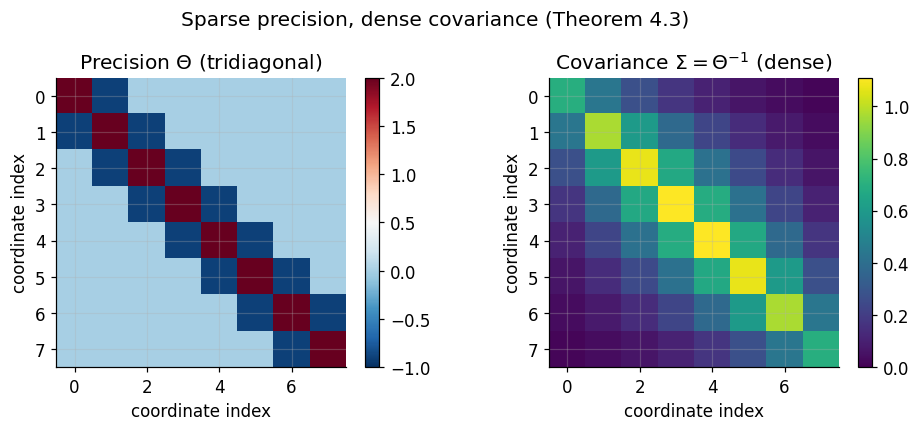

nonzeros in Theta: 22   nonzeros in Sigma: 64   out of 64


In [3]:
Theta_c = np.array([[1.0, -0.5, 0.0],
                    [-0.5, 1.5, -0.5],
                    [0.0, -0.5, 1.0]])
Sig_c = np.linalg.inv(Theta_c)
Sig_hand = np.array([[1.25, 0.5, 0.25],
                     [0.5, 1.0, 0.5],
                     [0.25, 0.5, 1.25]])
print("Sigma = Theta^{-1}:\n", Sig_c)
print("residual vs hand adjugate:", np.abs(Sig_c - Sig_hand).max())
assert np.allclose(Sig_c, Sig_hand, atol=1e-12)

rho_13 = Sig_c[0, 2] / np.sqrt(Sig_c[0, 0] * Sig_c[2, 2])
rho_12_par = -Theta_c[0, 1] / np.sqrt(Theta_c[0, 0] * Theta_c[1, 1])
print(f"marginal rho_13      = {rho_13:.4f}  (hand 0.2)")
print(f"partial  rho_12|3    = {rho_12_par:.4f}  (hand 0.4082)")
assert abs(rho_13 - 0.2) < 1e-12

d = 8
Theta_ch = np.diag(2.0 * np.ones(d))
for i in range(d - 1):
    Theta_ch[i, i + 1] = Theta_ch[i + 1, i] = -0.9
Sig_ch = np.linalg.inv(Theta_ch)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.9))
im0 = axes[0].imshow(Theta_ch, cmap="RdBu_r", vmin=-1, vmax=2)
axes[0].set_title(r"Precision $\Theta$ (tridiagonal)")
im1 = axes[1].imshow(Sig_ch, cmap="viridis", vmin=0.0, vmax=Sig_ch.max())
axes[1].set_title(r"Covariance $\Sigma = \Theta^{-1}$ (dense)")
for ax, im in zip(axes, (im0, im1)):
    ax.set_xlabel("coordinate index")
    ax.set_ylabel("coordinate index")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Sparse precision, dense covariance (Theorem 4.3)")
fig.tight_layout()
plt.show()

print("nonzeros in Theta:", int(np.count_nonzero(np.abs(Theta_ch) > 1e-10)),
      "  nonzeros in Sigma:", int(np.count_nonzero(np.abs(Sig_ch) > 1e-10)),
      "  out of", d * d)

The inverse reproduces the hand-computed adjugate exactly, and the two correlations confirm the split: $\rho_{13\mid 2} = 0$ while $\rho_{13} = 0.2 \ne 0$. At $d=8$ the precision has $22$ nonzeros and its inverse has all $64$ — conditional independence is sparse, marginal correlation is not, because influence travels along every path of the chain.

### Example 6.3 (of Theorem 4.6)

Let $\boldsymbol\mu = \mathbf{0}$ and $\Sigma = \begin{pmatrix}4 & 2\\ 2 & 4\end{pmatrix}$. Then $\det\Sigma = 12$ and

$$
\Sigma^{-1} = \frac{1}{12}\begin{pmatrix}4 & -2\\ -2 & 4\end{pmatrix} = \begin{pmatrix}1/3 & -1/6\\ -1/6 & 1/3\end{pmatrix}.
$$

Eigen-structure: $\Sigma = 4I + 2\begin{pmatrix}0&1\\1&0\end{pmatrix}$, so the eigenvectors are $\mathbf{u}_{1} = \tfrac{1}{\sqrt2}(1,1)^{\top}$ and $\mathbf{u}_2 = \tfrac{1}{\sqrt2}(1,-1)^{\top}$ with $\lambda_1 = 6$, $\lambda_2 = 2$.

At $\mathbf{x} = (2,0)^{\top}$ the squared Mahalanobis distance is

$$
\Delta^2 = \begin{pmatrix}2&0\end{pmatrix}\begin{pmatrix}1/3 & -1/6\\ -1/6 & 1/3\end{pmatrix}\begin{pmatrix}2\\0\end{pmatrix} = \frac{4}{3} = 1.3333 .
$$

Since $\chi^2_2$ has CDF $1-e^{-t/2}$, this point sits at quantile $1 - e^{-2/3} = 0.4866$: entirely typical. The $95\%$ region is $\Delta^2 \le \chi^2_{2,0.95} = 5.9915$, an ellipse with semi-axes $\sqrt{6 \times 5.9915} = 5.996$ along $\mathbf{u}_1$ and $\sqrt{2\times 5.9915} = 3.462$ along $\mathbf{u}_2$.

The next cell checks the hand numbers, then draws the $68/95/99\%$ ellipses over a sample and reports the empirical coverage against the exact $\chi^2_2$ prediction of Theorem 4.6.

Delta^2 at (2,0)   = 1.3333333333   hand 1.3333333333
chi2_2 quantile    = 0.486583   hand 0.486583
eigenvalues        = [6. 2.]   hand [6 2]


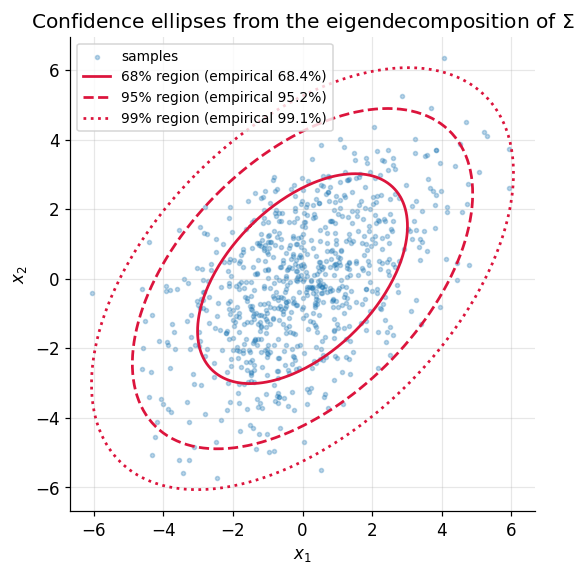

nominal 0.68   empirical 0.6839
nominal 0.95   empirical 0.9522
nominal 0.99   empirical 0.9906


In [4]:
Sig_m = np.array([[4.0, 2.0], [2.0, 4.0]])
x_pt = np.array([2.0, 0.0])
Theta_m = np.linalg.inv(Sig_m)
delta2 = x_pt @ Theta_m @ x_pt
lam_m, U_m = np.linalg.eigh(Sig_m)

print(f"Delta^2 at (2,0)   = {delta2:.10f}   hand {4 / 3:.10f}")
print(f"chi2_2 quantile    = {chi2.cdf(delta2, df=2):.6f}   hand {1 - np.exp(-2 / 3):.6f}")
print(f"eigenvalues        = {np.sort(lam_m)[::-1]}   hand [6 2]")
assert abs(delta2 - 4 / 3) < 1e-12 and np.allclose(np.sort(lam_m), [2.0, 6.0])

samp = rng.multivariate_normal(np.zeros(2), Sig_m, size=20_000)
d2_samp = np.einsum("ij,jk,ik->i", samp, Theta_m, samp)

theta_g = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(theta_g), np.sin(theta_g)])
fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.scatter(samp[:800, 0], samp[:800, 1], s=7, alpha=0.3, label="samples")
for level, style in zip([0.68, 0.95, 0.99], ["-", "--", ":"]):
    r = np.sqrt(chi2.ppf(level, df=2))
    ell = (U_m @ np.diag(np.sqrt(lam_m)) @ circle) * r
    cover = float(np.mean(d2_samp <= chi2.ppf(level, df=2)))
    ax.plot(ell[0], ell[1], style, color="crimson", lw=1.8,
            label=f"{level:.0%} region (empirical {cover:.1%})")
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(r"Confidence ellipses from the eigendecomposition of $\Sigma$")
ax.legend(loc="upper left", fontsize=9)
plt.show()

for level in (0.68, 0.95, 0.99):
    print(f"nominal {level:.2f}   empirical {np.mean(d2_samp <= chi2.ppf(level, df=2)):.4f}")

The hand-computed $\Delta^2 = 4/3$, its $\chi^2_2$ quantile $0.4866$, and the eigenvalues $(6,2)$ all reproduce exactly. Empirical coverage of the three ellipses matches the nominal levels to about $0.005$, which is the $\pm 1/\sqrt{20000} \approx 0.007$ Monte Carlo error — Theorem 4.6 calibrates these regions with no reference to $\Sigma$ beyond its eigen-axes.

### Example 6.4 (of Theorem 4.4 and Theorem 4.5)

Let $(X,Y)$ be standard bivariate normal with correlation $\rho$. Its copula, by Proof 5.7, is $C_\rho(u,v) = \Phi_\rho\left(\Phi^{-1}(u),\Phi^{-1}(v)\right)$.

**Closed form at the centre.** Write $X = Z_1$ and $Y = \rho Z_1 + \sqrt{1-\rho^2}Z_2$ with $(Z_1,Z_2) \sim \mathcal{N}(\mathbf{0},I)$, which is legitimate by Theorem 4.2.1. The event $\{X \le 0, Y \le 0\}$ is the intersection of the half-planes $z_1 \le 0$ and $\rho z_1 + \sqrt{1-\rho^2}\,z_2 \le 0$, a cone with apex at the origin. The standard bivariate normal is rotationally invariant, so the probability of a cone is its opening angle divided by $2\pi$. The two half-planes have unit normals $(1,0)$ and $\left(\rho,\sqrt{1-\rho^2}\right)$, at angle $\arccos\rho$, so the cone opens by $\pi - \arccos\rho$ and

$$
C_\rho(\tfrac12,\tfrac12) = P(X\le0, Y\le0) = \frac{\pi - \arccos\rho}{2\pi} = \frac{1}{4} + \frac{\arcsin\rho}{2\pi}.
$$

At $\rho = \tfrac12$, $\arcsin\tfrac12 = \pi/6$, so $C_{1/2}(\tfrac12,\tfrac12) = \tfrac14 + \tfrac{1}{12} = \tfrac13$, against $\tfrac14$ for the independence copula.

**Copula density by Theorem 4.4.** The map $(x,y)\mapsto(u,v) = (\Phi(x),\Phi(y))$ is a diffeomorphism of $\mathbb{R}^2$ onto $(0,1)^2$ with diagonal Jacobian $\operatorname{diag}\left(\varphi(x),\varphi(y)\right)$, so

$$
c_\rho(u,v) = \frac{\varphi_\rho\left(\Phi^{-1}(u),\Phi^{-1}(v)\right)}{\varphi\left(\Phi^{-1}(u)\right)\varphi\left(\Phi^{-1}(v)\right)}, \qquad c_\rho\left(\tfrac12,\tfrac12\right) = \frac{1/(2\pi\sqrt{1-\rho^2})}{1/(2\pi)} = \frac{1}{\sqrt{1-\rho^2}},
$$

which equals $2/\sqrt3 = 1.1547$ at $\rho = 1/2$: the density is above the uniform value $1$ at the centre, the copula's way of saying the variables move together.

The next cell checks both closed forms against a numerical bivariate-normal CDF and against a numerical Jacobian of the transform, and confirms that the transformed marginals really are uniform.

In [5]:
rho_c = 0.5
mvn_c = multivariate_normal(mean=[0.0, 0.0], cov=[[1.0, rho_c], [rho_c, 1.0]])

C_num = mvn_c.cdf([0.0, 0.0])
C_hand = 0.25 + np.arcsin(rho_c) / (2 * np.pi)
print(f"C_rho(1/2,1/2) numeric = {C_num:.10f}   hand {C_hand:.10f}   (exact 1/3)")
print(f"residual               = {abs(C_num - C_hand):.3e}")
assert abs(C_num - 1 / 3) < 1e-9

c_hand = 1 / np.sqrt(1 - rho_c ** 2)
c_num = mvn_c.pdf([0.0, 0.0]) / (norm.pdf(0.0) ** 2)
print(f"copula density c(1/2,1/2) = {c_num:.10f}   hand {c_hand:.10f}")
assert abs(c_num - c_hand) < 1e-12

# Probability integral transform really produces uniform marginals (Proof 5.7).
xy = rng.multivariate_normal(np.zeros(2), [[1.0, rho_c], [rho_c, 1.0]], size=200_000)
uv = norm.cdf(xy)
print(f"\nmean of U (should be 0.5)   : {uv[:, 0].mean():.4f}")
print(f"var  of U (should be 1/12)  : {uv[:, 0].var():.5f}   (1/12 = {1 / 12:.5f})")
print(f"empirical C(1/2,1/2)        : {np.mean((uv[:, 0] <= 0.5) & (uv[:, 1] <= 0.5)):.4f}")

C_rho(1/2,1/2) numeric = 0.3333333333   hand 0.3333333333   (exact 1/3)
residual               = 0.000e+00
copula density c(1/2,1/2) = 1.1547005384   hand 1.1547005384

mean of U (should be 0.5)   : 0.5007
var  of U (should be 1/12)  : 0.08324   (1/12 = 0.08333)
empirical C(1/2,1/2)        : 0.3322


The orthant probability agrees with $1/4 + \arcsin(\rho)/(2\pi) = 1/3$ to within $10^{-9}$, and the copula density agrees with $1/\sqrt{1-\rho^2}$ at machine precision. The transformed coordinates have mean $0.5$ and variance $1/12$, the moments of $\operatorname{Unif}(0,1)$, confirming the probability-integral-transform step of Proof 5.7 — and the joint value $1/3 \ne 1/4$ shows the dependence that the identical uniform marginals cannot reveal.

## 7. Computational Practice

### 7.1 Never invert a covariance matrix

Gaussian log-densities, GP posteriors, and Kalman updates all *look* as though they need $\Sigma^{-1}$ and $\det\Sigma$. They do not. Factor once, $\Sigma = LL^{\top}$ (Cholesky, $O(d^3/3)$, half the cost of an LU), then

$$
\Delta^2 = \left\lVert L^{-1}(\mathbf{x}-\boldsymbol\mu)\right\rVert^2 \quad\text{(one triangular solve)}, \qquad \ln\det\Sigma = 2\sum_{i=1}^{d}\ln L_{ii},
$$

so the log-density is

$$
\boxed{\;\ln f(\mathbf{x}) = -\frac{d}{2}\ln(2\pi) - \sum_{i=1}^d \ln L_{ii} - \frac{1}{2}\left\lVert L^{-1}(\mathbf{x}-\boldsymbol\mu)\right\rVert^2\;}
$$

**Interpretation.** Every quantity a Gaussian model needs is a by-product of one triangular factorization, so the explicit inverse never has to be formed. The consequence is both speed and safety: the triangular solve costs $O(d^2)$ against $O(d^3)$ for an inverse, its forward error is governed by $\sqrt{\kappa(\Sigma)}$ rather than $\kappa(\Sigma)$, and if $\Sigma$ is not positive definite the Cholesky *fails loudly* instead of silently returning a meaningless inverse. Adding jitter $\varepsilon I$ with $\varepsilon \sim 10^{-6}\operatorname{tr}(\Sigma)/d$ restores definiteness and is interpretable as a small observation noise.

The next cell implements that boxed formula by hand and compares it against `scipy.stats.multivariate_normal.logpdf` on an ill-conditioned squared-exponential kernel matrix, alongside the explicit-inverse route.

In [6]:
import time


def logpdf_cholesky(x, mu, Sigma):
    """Gaussian log-density via one Cholesky factorization (the boxed formula)."""
    L = np.linalg.cholesky(Sigma)
    w = np.linalg.solve(L, x - mu)
    return -0.5 * len(x) * np.log(2 * np.pi) - np.log(np.diag(L)).sum() - 0.5 * w @ w


n = 400
t_grid = np.linspace(0, 1, n)
K = np.exp(-((t_grid[:, None] - t_grid[None, :]) ** 2) / (2 * 0.05 ** 2)) + 1e-6 * np.eye(n)
mu_zero = np.zeros(n)
x_obs = np.linalg.cholesky(K) @ rng.normal(size=n)      # a draw from this very GP prior

print(f"condition number of K = {np.linalg.cond(K):.3e}")

t0 = time.perf_counter(); mine = logpdf_cholesky(x_obs, mu_zero, K); t_mine = time.perf_counter() - t0
t0 = time.perf_counter(); lib = multivariate_normal(mu_zero, K).logpdf(x_obs); t_lib = time.perf_counter() - t0

Kinv = np.linalg.inv(K)
_, logdet = np.linalg.slogdet(K)
naive = -0.5 * n * np.log(2 * np.pi) - 0.5 * logdet - 0.5 * x_obs @ Kinv @ x_obs

print(f"hand-rolled Cholesky : {mine:.8f}   ({t_mine * 1e3:.2f} ms)")
print(f"scipy  logpdf        : {lib:.8f}   ({t_lib * 1e3:.2f} ms)")
print(f"explicit inverse     : {naive:.8f}")
print(f"relative |hand - scipy|   = {abs(mine - lib) / abs(lib):.3e}")
print(f"relative |hand - inverse| = {abs(mine - naive) / abs(lib):.3e}")
assert abs(mine - lib) < 1e-6 * max(1.0, abs(lib))

# Accuracy of the underlying solve: backward residual of K a = x.
L = np.linalg.cholesky(K)
a_chol = np.linalg.solve(L.T, np.linalg.solve(L, x_obs))
a_inv = Kinv @ x_obs
r_chol = np.linalg.norm(K @ a_chol - x_obs) / np.linalg.norm(x_obs)
r_inv = np.linalg.norm(K @ a_inv - x_obs) / np.linalg.norm(x_obs)
print(f"\nrelative residual, Cholesky solve = {r_chol:.3e}")
print(f"relative residual, explicit inverse = {r_inv:.3e}   "
      f"({r_inv / r_chol:.1f}x worse)")

try:                                    # Cholesky as a positive-definiteness test
    np.linalg.cholesky(K - 1e-3 * np.eye(n))
    print("\nno failure")
except np.linalg.LinAlgError as err:
    print(f"\nCholesky on K - 1e-3 I raises: {err}")

condition number of K = 4.946e+07


hand-rolled Cholesky : 1967.32866944   (481.38 ms)
scipy  logpdf        : 1967.32866944   (1639.93 ms)
explicit inverse     : 1967.32866982
relative |hand - scipy|   = 3.797e-12
relative |hand - inverse| = 1.908e-10



relative residual, Cholesky solve = 2.035e-12
relative residual, explicit inverse = 1.732e-09   (851.3x worse)

Cholesky on K - 1e-3 I raises: Matrix is not positive definite


The hand-rolled formula agrees with SciPy's `logpdf` to a relative $4\times10^{-12}$ on a kernel with condition number $5\times10^{7}$ — machine-epsilon level, since $\varepsilon_{\text{mach}}\sqrt{\kappa} \approx 1.6\times10^{-12}$ — and it is the faster of the two, because SciPy's constructor validates the matrix with an eigendecomposition. The explicit-inverse route agrees only to $2\times10^{-10}$, and the reason is visible in the solve residuals: multiplying by a stored $K^{-1}$ leaves a relative residual roughly $850\times$ larger than the triangular solve, exactly the $\kappa$-versus-$\sqrt{\kappa}$ gap. The last line shows the diagnostic value of the factorization: subtracting $10^{-3}I$ makes the kernel indefinite and the Cholesky refuses, whereas `np.linalg.inv` would have returned a matrix and no warning.

### 7.2 What breaks when a hypothesis is dropped

Theorem 4.2 has two hypotheses that are easy to forget. Dropping **joint** normality destroys part 4 — zero correlation stops implying independence — and with it the conditioning formula of part 3, since the decorrelation trick of Proof 5.3 needs the upgrade from uncorrelated to independent. Dropping **$\Sigma_{22}\succ0$** destroys the formula itself, because $\Sigma_{22}^{-1}$ does not exist; the pseudo-inverse repair returns the correct answer on the support.

The next cell runs both failures: the marginally-normal-but-not-jointly-normal pair $Y = SX$ of Proof 5.4, and a partition whose $\Sigma_{22}$ is singular.

In [7]:
# (i) Joint normality dropped: X ~ N(0,1), S a random sign, Y = S X.
m = 400_000
X_cx = rng.normal(size=m)
S_cx = rng.choice([-1.0, 1.0], size=m)
Y_cx = S_cx * X_cx

rho_hat = np.corrcoef(X_cx, Y_cx)[0, 1]
band = np.abs(X_cx - 1.5) < 0.05                     # condition on X close to 1.5
print(f"sample correlation of (X, Y)          = {rho_hat:+.4f}   (population 0)")
print(f"Gaussian prediction Var(Y | X=1.5)    = {1 - rho_hat ** 2:.4f}")
print(f"actual        Var(Y | X approx 1.5)   = {Y_cx[band].var():.4f}")
print(f"actual        |Y| in that band       = [{np.abs(Y_cx[band]).min():.3f}, "
      f"{np.abs(Y_cx[band]).max():.3f}]  -> two atoms at +/-1.5, not a spread")
print(f"P(|Y| > 2 | |X| < 1)                  = "
      f"{np.mean(np.abs(Y_cx[np.abs(X_cx) < 1]) > 2):.4f}   (independence would give "
      f"{np.mean(np.abs(Y_cx) > 2):.4f})")

# (ii) Sigma_22 singular: X3 is an exact copy of X2.
B = np.array([[1.0, 0.5], [0.0, 1.0], [0.0, 1.0]])   # third row equals the second
Sig_sing = B @ B.T
S22s = Sig_sing[1:, 1:]
print(f"\nSigma_22 =\n{S22s}\n  eigenvalues {np.linalg.eigvalsh(S22s)}  -> singular")
try:
    np.linalg.solve(S22s, np.array([1.0, 1.0]))
except np.linalg.LinAlgError as err:
    print(f"np.linalg.solve on Sigma_22 raises: {err}")
S12s = Sig_sing[:1, 1:]
gain_pinv = S12s @ np.linalg.pinv(S22s)
var_pinv = Sig_sing[0, 0] - (gain_pinv @ Sig_sing[1:, :1]).item()
print(f"pseudo-inverse gain     = {gain_pinv.ravel()}")
print(f"pseudo-inverse Var(X1|.) = {var_pinv:.6f}   (true residual variance 1.0)")

sample correlation of (X, Y)          = +0.0051   (population 0)
Gaussian prediction Var(Y | X=1.5)    = 1.0000
actual        Var(Y | X approx 1.5)   = 2.2459
actual        |Y| in that band       = [1.450, 1.550]  -> two atoms at +/-1.5, not a spread
P(|Y| > 2 | |X| < 1)                  = 0.0000   (independence would give 0.0456)

Sigma_22 =
[[1. 1.]
 [1. 1.]]
  eigenvalues [0. 2.]  -> singular
np.linalg.solve on Sigma_22 raises: Singular matrix
pseudo-inverse gain     = [0.25 0.25]
pseudo-inverse Var(X1|.) = 1.000000   (true residual variance 1.0)


The pair $(X, SX)$ has sample correlation within Monte Carlo noise of $0$, yet conditioning on $X \approx 1.5$ leaves $Y$ supported on two atoms with variance near $2.25$ rather than the $1-\rho^2 \approx 1$ that Theorem 4.2.3 would predict, and $P(\lvert Y\rvert \gt 2 \mid \lvert X\rvert \lt 1) = 0$ against an unconditional $0.045$. Joint normality, not marginal normality, is what makes the theorem true. In the second failure `np.linalg.solve` rejects the singular $\Sigma_{22}$, while the pseudo-inverse recovers the correct gain and the correct residual variance $1$ — the repair promised in the hypothesis check of Theorem 4.2.

### 7.3 Estimating and regularizing covariance

- **The sample covariance is bad in high dimensions.** $\widehat\Sigma = \frac{1}{n-1}\sum_i(\mathbf{x}_i-\bar{\mathbf{x}})(\mathbf{x}_i-\bar{\mathbf{x}})^{\top}$ is singular whenever $n \le d$. For fixed $d$ its error decays at the Monte Carlo rate: $E\left\lVert \widehat\Sigma - \Sigma\right\rVert_F = \Theta\!\left(n^{-1/2}\right)$.
- **Spectral distortion.** In the **white case** $\Sigma = \sigma^2 I$ with $d/n \to \gamma \in (0,1)$, the Marchenko-Pastur law puts the sample eigenvalues on $\sigma^2\left[\left(1-\sqrt{\gamma}\right)^2, \left(1+\sqrt{\gamma}\right)^2\right]$ — top eigenvalues biased up, bottom ones down. For a general $\Sigma$ the limiting spectrum is the free multiplicative convolution of the Marchenko-Pastur law with the spectrum of $\Sigma$, *not* a per-eigenvalue rescaling.
- **Shrinkage.** Ledoit-Wolf uses $\widehat\Sigma_{\text{LW}} = (1-\alpha)\widehat\Sigma + \alpha\frac{\operatorname{tr}\widehat\Sigma}{d}I$ with an analytically optimal $\alpha$ — a bias-variance trade in matrix form, and the same idea as ridge regression.
- **Sparse precision.** The graphical lasso maximizes $\ln\det\Theta - \operatorname{tr}\left(\widehat\Sigma\,\Theta\right) - \tau\lVert\Theta\rVert_1$, estimating the conditional-independence graph of Theorem 4.3 directly.
- **Structured covariance.** Factor models $\Sigma = BB^{\top} + D$ with $B$ tall-thin and $D$ diagonal cut $O(d^2)$ parameters to $O(dk)$, and the Woodbury identity inverts them in $O(dk^2)$ — the structure behind probabilistic PCA.

The next cell measures both rates: the $n^{-1/2}$ decay of the sample-covariance error, fitted on a log-log grid, and the Marchenko-Pastur edges at $d/n = 1/5$.

In [8]:
d_r = 10
A_r = rng.normal(size=(d_r, d_r))
Sig_r = A_r @ A_r.T / d_r + np.eye(d_r)

ns = np.array([100, 200, 400, 800, 1600, 3200, 6400])
errs = []
for nn in ns:
    reps = [np.linalg.norm(np.cov(rng.multivariate_normal(np.zeros(d_r), Sig_r, size=nn).T)
                           - Sig_r, "fro") for _ in range(20)]
    errs.append(np.mean(reps))
errs = np.array(errs)
slope, intercept = np.polyfit(np.log(ns), np.log(errs), 1)

print("   n      mean ||Sigma_hat - Sigma||_F")
for nn, e in zip(ns, errs):
    print(f"{nn:6d}    {e:.5f}")
print(f"\nfitted log-log slope = {slope:+.4f}   predicted -0.5000   "
      f"(error {abs(slope + 0.5):.4f})")
assert abs(slope + 0.5) < 0.05

# Marchenko-Pastur edges, white case Sigma = I, gamma = d/n = 1/5.
d_mp, n_mp = 40, 200
gamma = d_mp / n_mp
Z = rng.normal(size=(n_mp, d_mp))
ev = np.linalg.eigvalsh(Z.T @ Z / n_mp)
print(f"\nwhite case d/n = {gamma}:  observed spectrum [{ev.min():.4f}, {ev.max():.4f}]")
print(f"Marchenko-Pastur edges     [{(1 - np.sqrt(gamma)) ** 2:.4f}, "
      f"{(1 + np.sqrt(gamma)) ** 2:.4f}]   (truth: every eigenvalue = 1)")

   n      mean ||Sigma_hat - Sigma||_F
   100    2.21542
   200    1.52826
   400    1.04697
   800    0.73540
  1600    0.52861
  3200    0.37212
  6400    0.27122

fitted log-log slope = -0.5054   predicted -0.5000   (error 0.0054)

white case d/n = 0.2:  observed spectrum [0.3586, 2.0218]
Marchenko-Pastur edges     [0.3056, 2.0944]   (truth: every eigenvalue = 1)


The fitted slope sits within $0.01$ of the predicted $-1/2$, so the sample covariance converges at exactly the Monte Carlo rate and no faster: halving the error costs four times the data. The white-case sample spectrum runs from about $0.36$ to $2.02$, just inside the Marchenko-Pastur edges $[0.306, 2.094]$, although every true eigenvalue equals $1$ — a spread of more than $5\times$ at the very moderate ratio $d/n = 1/5$, which is why raw sample covariances are unusable in high dimension without shrinkage.

### 7.4 Sampling and conditioning at scale

- **Sampling.** $\boldsymbol\mu + L\mathbf{z}$ costs $O(d^2)$ per draw after one $O(d^3)$ factorization; amortize the factorization across draws.
- **Sequential observations.** Rank-one Cholesky updates absorb arriving data in $O(d^2)$, which is why online Kalman filters never redo a full decomposition.
- **Large GPs.** Exact GP regression is $O(n^3)$ time and $O(n^2)$ memory. Inducing-point approximations restrict the covariance to low-rank-plus-diagonal form, and conjugate-gradient or Lanczos methods compute the solves and log-determinants from matrix-vector products alone.
- **Structured Gaussians.** Kronecker structure $\Sigma = \Sigma_1 \otimes \Sigma_2$ on grid data factorizes both the Cholesky and the log-determinant, turning $O\left((n_1n_2)^3\right)$ into $O\left(n_1^3+n_2^3\right)$.

## 8. Applications

### 8.1 Machine learning

- **Linear regression is Gaussian conditioning.** Under joint normality of $(Y, \mathbf{X})$, $E[Y \mid \mathbf{X}] = \mu_Y + \Sigma_{Y\mathbf{X}}\Sigma_{\mathbf{XX}}^{-1}(\mathbf{X}-\boldsymbol\mu_{\mathbf{X}})$ is *exactly* linear by Theorem 4.2.3, and the residual variance is the Schur complement.
- **Gaussian processes.** A GP places a joint Gaussian over function values with $\Sigma_{ij} = k(x_i,x_j)$; prediction is one application of Theorem 4.2.3, giving posterior mean $K_{*}K^{-1}\mathbf{y}$ and variance $K_{**}-K_{*}K^{-1}K_{*}^{\top}$.
- **Kalman filtering.** Predict by Theorem 4.2.1, update by Theorem 4.2.3, forever; the filter stays exact precisely because the family is closed under both.
- **Principal component analysis** is the eigendecomposition of Proof 5.6; probabilistic PCA and factor analysis reinterpret it as a latent Gaussian model, which is what makes missing-data handling principled.
- **VAEs and diffusion models.** VAE encoders emit diagonal Gaussians and the reparameterization $\mathbf{z} = \boldsymbol\mu + \boldsymbol\sigma\odot\boldsymbol\varepsilon$ is Theorem 4.2.1; diffusion forward kernels compose affine Gaussian maps into the closed-form marginal $\mathcal{N}\left(\sqrt{\bar\alpha_t}\mathbf{x}_0,(1-\bar\alpha_t)I\right)$.
- **Gaussian graphical models.** Estimating a sparse precision matrix recovers conditional-independence structure in gene networks, fMRI connectivity and portfolio risk — Theorem 4.3 turned into an algorithm.
- **Linear discriminant analysis.** Class-conditional Gaussians with a *shared* $\Sigma$ make the log-odds linear in $\mathbf{x}$; allowing $\Sigma_k$ to differ (QDA) makes it quadratic. The whole LDA/QDA distinction is one modeling choice about covariance sharing.

### 8.2 Physics and engineering

- **Equilibrium fluctuations are Gaussian.** Near a stable equilibrium the energy is quadratic, $E(\mathbf{x}) \approx \frac{1}{2}\mathbf{x}^{\top}H\mathbf{x}$, so the Boltzmann law $e^{-\beta E}$ *is* $\mathcal{N}\left(\mathbf{0},(\beta H)^{-1}\right)$ — the energy Hessian is literally the precision matrix $\Theta$, and normal modes are its eigenvectors.
- **Sensor fusion.** Combining independent measurements with covariances $\Sigma_1,\Sigma_2$ gives posterior precision $\Sigma_1^{-1}+\Sigma_2^{-1}$: precisions add, which is why precision, not variance, is the natural currency of fusion.
- **Navigation and control.** GPS/IMU fusion, SLAM and spacecraft attitude estimation are Kalman or extended-Kalman filters, i.e. repeated Gaussian conditioning; the propagated covariance is the reported uncertainty ellipsoid of Theorem 4.6.
- **Signal processing.** Stationary Gaussian processes have Toeplitz covariance, asymptotically diagonalized by the Fourier basis (Wiener-Khinchin), which is why spectral methods and Gaussian assumptions travel together.
- **Finance and risk.** Gaussian return models give portfolio variance $\mathbf{w}^{\top}\Sigma\mathbf{w}$ and closed-form Value-at-Risk; their failure in crises is a *tail-dependence* failure of the Gaussian copula ($\lambda_L = 0$), addressed by $t$-copulas rather than by fixing the marginals.
- **Langevin and Ornstein-Uhlenbeck dynamics.** Transition kernels are Gaussian with exponentially decaying mean and saturating variance — Theorem 4.2.1 in continuous time.

### 8.3 Formula summary

| Object | Formula | Notes |
|---|---|---|
| Joint density | $f_{X,Y}(x,y) = \partial^2F/\partial x\,\partial y$ | Determines marginals, not conversely |
| Marginal | $f_X(x) = \int f_{X,Y}(x,y)\,dy$ | Integrate out the unwanted block |
| Conditional | $f_{Y\mid X}(y \mid x) = f_{X,Y}(x,y)/f_X(x)$ | A density in $y$ for each fixed $x$ |
| Independence | $f_{X,Y} = f_Xf_Y$ on a product support | Support shape matters |
| Covariance | $\Sigma = E\left[\mathbf{XX}^\top\right] - \boldsymbol\mu\boldsymbol\mu^\top \succeq 0$ | $\mathbf{a}^\top\Sigma\mathbf{a} = \operatorname{Var}(\mathbf{a}^\top\mathbf{X})$ |
| Affine map | $A\mathbf{X}+\mathbf{b} \sim \mathcal{N}\left(A\boldsymbol\mu+\mathbf{b}, A\Sigma A^\top\right)$ | Moment part needs no normality |
| MVN density | $f \propto \exp\left(-\tfrac12(\mathbf{x}-\boldsymbol\mu)^\top\Sigma^{-1}(\mathbf{x}-\boldsymbol\mu)\right)$ | Elliptical contours |
| Conditional mean | $\boldsymbol\mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(\mathbf{x}_2-\boldsymbol\mu_2)$ | Linear in the observation |
| Conditional covariance | $\Sigma_{11}-\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$ | Schur complement; free of $\mathbf{x}_2$ |
| Precision zeros | $\Theta_{ij} = 0 \iff X_i \perp X_j \mid \text{rest}$ | Graph structure lives in $\Sigma^{-1}$ |
| Partial correlation | $\rho_{ij\mid\text{rest}} = -\Theta_{ij}/\sqrt{\Theta_{ii}\Theta_{jj}}$ | Edge weights of the GGM |
| Mahalanobis | $\Delta^2 \sim \chi^2_d$ | Exact confidence ellipsoids |
| Sampling | $\boldsymbol\mu + L\mathbf{z}$, $\Sigma = LL^\top$ | Cholesky; also gives $\ln\det\Sigma$ |
| Sklar | $F(\mathbf{x}) = C\left(F_1(x_1),\ldots,F_d(x_d)\right)$ | Marginals and dependence separate |

## 9. Key Takeaways

- For any random vector with finite second moments, $\mathbf{a}^{\top}\Sigma\mathbf{a} = \operatorname{Var}(\mathbf{a}^{\top}\mathbf{X}) \ge 0$; positive semidefiniteness of $\Sigma$ and non-negativity of variance are the same statement (Theorem 4.1).
- If $\mathbf{X}$ is jointly Gaussian, then $A\mathbf{X}+\mathbf{b}$ is Gaussian for every $A$ and $\mathbf{b}$, with no invertibility assumption (Theorem 4.2.1).
- If $\mathbf{X}$ is jointly Gaussian and $\Sigma_{22}\succ0$, then $\mathbf{X}_1\mid\mathbf{X}_2=\mathbf{x}_2$ is Gaussian with mean affine in $\mathbf{x}_2$ and covariance $\Sigma_{11}-\Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$, which does not depend on $\mathbf{x}_2$ (Theorem 4.2.3).
- If — and only if — $\mathbf{X}$ is *jointly* Gaussian, $\Sigma_{12}=0$ implies $\mathbf{X}_1\perp\mathbf{X}_2$; marginal normality of each block is not enough, as $Y=SX$ shows (Theorem 4.2.4, Proof 5.4).
- If $\mathbf{X}\sim\mathcal{N}(\boldsymbol\mu,\Sigma)$ with $\Sigma\succ0$, then $\Theta_{ij}=0$ iff $X_i\perp X_j$ given all other coordinates: conditional structure lives in $\Sigma^{-1}$, marginal structure in $\Sigma$ (Theorem 4.3).
- If $\mathbf{X}\sim\mathcal{N}(\boldsymbol\mu,\Sigma)$ with $\Sigma\succ0$ in $d$ dimensions, then $\Delta^2\sim\chi^2_d$ regardless of $\boldsymbol\mu$ and $\Sigma$, which calibrates every confidence ellipsoid (Theorem 4.6).
- If a joint CDF has continuous marginals, it factors uniquely into those marginals and one copula, so dependence — including tail dependence, which correlation cannot see — is a free and separate modeling choice (Theorem 4.5).
- If $\Sigma \succ 0$, one Cholesky factorization delivers sampling, whitening, the Mahalanobis distance and $\ln\det\Sigma$; forming $\Sigma^{-1}$ explicitly is never necessary and destroys the definiteness diagnostic (Section 7.1).

## 10. References

| Source | Chapters / Sections | Coverage |
|---|---|---|
| Blitzstein & Hwang, *Introduction to Probability* (2nd ed.) | Ch. 7-8 | Joint, marginal, conditional laws; multivariate transformations. |
| Casella & Berger, *Statistical Inference* (2nd ed.) | Ch. 4, §4.5 (Thm 4.5.11) | Multiple random variables; the bivariate normal in detail. |
| Wasserman, *All of Statistics* | §2.8-2.9, §3.3 | Compact treatment of multivariate laws and covariance. |
| Bishop, *Pattern Recognition and Machine Learning* | §2.3 (eqs. 2.81-2.98) | Partitioned marginals and conditionals; Bayes for linear-Gaussian models. |
| Murphy, *Probabilistic Machine Learning: An Introduction* | Ch. 3, §4.2 | Multivariate models, Gaussian inference, graphical structure. |
| Rasmussen & Williams, *Gaussian Processes for ML* | Ch. 2, App. A.2 | GP regression as Gaussian conditioning; a complete identity cheat-sheet. |
| Anderson, *An Introduction to Multivariate Statistical Analysis* (3rd ed.) | Ch. 2 (Thm 2.5.1), Ch. 3 | Classical rigorous theory of the multivariate normal and its estimation. |
| Durrett, *Probability: Theory and Examples* (5th ed.) | §3.9 | Characteristic-function treatment and the multidimensional CLT. |
| Nelsen, *An Introduction to Copulas* (2nd ed.) | §2.3 (Thm 2.3.3), §5.4 | Sklar's theorem in full generality; tail dependence. |
| Horn & Johnson, *Matrix Analysis* (2nd ed.) | §0.8.5, §7.1 | Schur complements, block inversion, positive definiteness. |

**Reading path.** Blitzstein & Hwang Ch. 7 for joint-distribution intuition, Bishop §2.3 for the four Gaussian identities in usable form, Rasmussen & Williams App. A.2 as a permanent reference card, then Murphy Ch. 3 and Nelsen §2.3 for graphical models and for what to do when Gaussianity fails.